In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv("/Users/navikamaglani/Documents/personal/supply_chain_disruption_ai/data/processed/trade_features.csv")

df.head()

,CTY_CODE,CTY_NAME,GEN_VAL_MO,time,year,month,quarter,mom_change,rolling_3_month_avg,rolling_6_month_avg,historical_mean,historical_std,deviation_from_avg,high_disruption_risk
0,-,TOTAL FOR ALL COUNTRIES,195796204072,2020-01-01,2020,1,1,NaN,1.957962e+11,1.957962e+11,1.957962e+11,NaN,NaN,0
1,-,TOTAL FOR ALL COUNTRIES,178107959988,2020-02-01,2020,2,1,-0.090340,1.869521e+11,1.869521e+11,1.869521e+11,1.250748e+10,-0.707107,0
2,-,TOTAL FOR ALL COUNTRIES,193922847899,2020-03-01,2020,3,1,0.088794,1.892757e+11,1.892757e+11,1.892757e+11,9.716773e+09,0.478263,0
3,-,TOTAL FOR ALL COUNTRIES,165611885689,2020-04-01,2020,4,2,-0.145991,1.792142e+11,1.833597e+11,1.833597e+11,1.424561e+10,-1.245846,0
4,-,TOTAL FOR ALL COUNTRIES,163494079397,2020-05-01,2020,5,2,-0.012788,1.743429e+11,1.793866e+11,1.793866e+11,1.520302e+10,-1.045352,0


In [18]:
model_df = df.dropna(subset=[
    "mom_change",
    "rolling_3_month_avg",
    "rolling_6_month_avg",
    "deviation_from_avg",
    "high_disruption_risk"
])

features = [
    "GEN_VAL_MO",
    "rolling_3_month_avg",
    "rolling_6_month_avg",
    "month",
    "quarter"
]

X = model_df[features]
y = model_df["high_disruption_risk"]

print(X.shape)
print(y.value_counts())

(17758, 5)
high_disruption_risk
0    13058
1     4700
Name: count, dtype: int64


In [20]:
# Keep only selected columns + target
model_df = model_df[features + ["high_disruption_risk"]]

# Remove inf values
model_df = model_df.replace([np.inf, -np.inf], np.nan)

# Drop NaNs
model_df = model_df.dropna()

# Recreate X and y
X = model_df[features]
y = model_df["high_disruption_risk"]

print(X.shape)
print(y.value_counts())

(17758, 5)
high_disruption_risk
0    13058
1     4700
Name: count, dtype: int64


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_log))
print("AUC:", roc_auc_score(y_test, y_proba_log))

              precision    recall  f1-score   support

           0       0.74      1.00      0.85      2612
           1       0.00      0.00      0.00       940

    accuracy                           0.74      3552
   macro avg       0.37      0.50      0.42      3552
weighted avg       0.54      0.74      0.62      3552

AUC: 0.6698832719689811


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [23]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0       0.92      0.80      0.86      2612
           1       0.60      0.82      0.69       940

    accuracy                           0.81      3552
   macro avg       0.76      0.81      0.77      3552
weighted avg       0.84      0.81      0.81      3552

AUC: 0.8836926949268514


In [24]:
importance_df = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
0,GEN_VAL_MO,0.496541
1,rolling_3_month_avg,0.280152
2,rolling_6_month_avg,0.197507
3,month,0.020079
4,quarter,0.005720


In [25]:
import shap

In [26]:
explainer = shap.TreeExplainer(rf_model)

In [27]:
shap_values = explainer.shap_values(X_test)

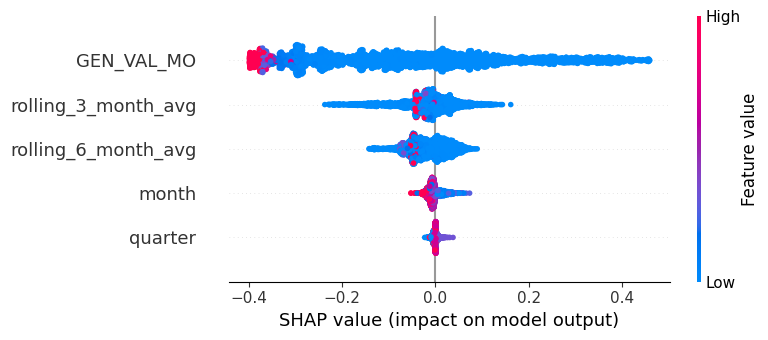

In [30]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)